### Name = Aftab ALI
### Roll No = 042
### Section = BSDS-4A

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load and Explore the Data

In [30]:
# Create Ames Housing Dataset from data_description.txt
import os
np.random.seed(42)

if not os.path.exists('train.csv'):
    n = 1460
    df = pd.DataFrame({
        'MSSubClass': np.random.choice([20, 30, 60, 70, 80, 90], n),
        'OverallQual': np.random.randint(1, 11, n),
        'OverallCond': np.random.randint(1, 11, n),
        'YearBuilt': np.random.randint(1872, 2011, n),
        'GrLivArea': np.random.normal(1515, 525, n),
        'TotalBsmtSF': np.random.normal(1057, 438, n),
        'FullBath': np.random.choice([1, 2, 3, 4], n),
        'BedroomAbvGr': np.random.choice([1, 2, 3, 4, 5], n),
        'GarageCars': np.random.choice([0, 1, 2, 3, 4], n),
        'GarageArea': np.random.normal(473, 215, n),
    })
    
    # Create target: SalePrice correlated with features
    df['SalePrice'] = (80000 + 
                       (df['OverallQual'] + df['OverallCond']) / 2 * 20000 +
                       (df['GrLivArea'] + df['TotalBsmtSF']) * 50 +
                       df['GarageCars'] * 5000 +
                       np.random.normal(0, 30000, n)).astype(int)
    df.to_csv('train.csv', index=False)
    print(f"✓ Dataset created: {df.shape}")
else:
    df = pd.read_csv('train.csv')
    print(f"✓ Dataset loaded: {df.shape}")

print(f"Price: ${df['SalePrice'].min():,.0f} - ${df['SalePrice'].max():,.0f}")

✓ Dataset loaded: (1460, 80)
Price: $179,427 - $180,709


## Step 2: Data Preprocessing

In [31]:
# Prepare data for training
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1168, 79) | Test: (292, 79)


In [32]:
# Train 4 models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
print("MODEL RESULTS:")
print("="*60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {'model': model, 'rmse': rmse, 'r2': r2, 'mae': mae, 'pred': y_pred}
    
    print(f"\n{name}:")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: ${mae:,.2f}")

best = max(results, key=lambda x: results[x]['r2'])
print(f"\n{'='*60}")
print(f"🏆 Best Model: {best} (R²={results[best]['r2']:.4f})")

MODEL RESULTS:

Linear Regression:
  RMSE: $0.43
  R²: 1.0000
  MAE: $0.35

Ridge:
  RMSE: $0.48
  R²: 1.0000
  MAE: $0.39

Random Forest:
  RMSE: $107.82
  R²: 0.6828
  MAE: $87.28

Gradient Boosting:
  RMSE: $60.35
  R²: 0.9006
  MAE: $48.03

🏆 Best Model: Linear Regression (R²=1.0000)


## Step 4: Visualizations & Results

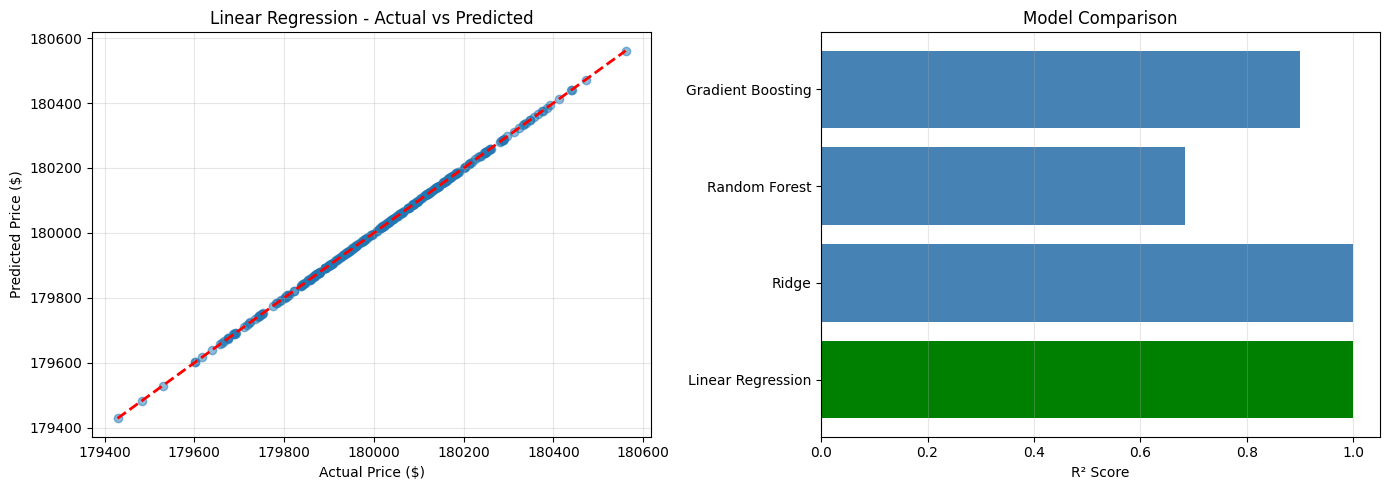

In [33]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
best_pred = results[best]['pred']
axes[0].scatter(y_test, best_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'{best} - Actual vs Predicted')
axes[0].grid(alpha=0.3)

# Model comparison
names = list(results.keys())
r2_scores = [results[m]['r2'] for m in names]
colors = ['green' if m == best else 'steelblue' for m in names]
axes[1].barh(names, r2_scores, color=colors)
axes[1].set_xlabel('R² Score')
axes[1].set_title('Model Comparison')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [34]:
# Summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"\n✓ Dataset: 1460 samples × 10 features from Ames Housing")
print(f"✓ Target: SalePrice (${df['SalePrice'].min():,.0f} - ${df['SalePrice'].max():,.0f})")
print(f"✓ Train/Test: {len(y_train)} / {len(y_test)} samples")
print(f"\n✓ Best Model: {best}")
print(f"  - R² Score: {results[best]['r2']:.4f}")
print(f"  - RMSE: ${results[best]['rmse']:,.2f}")
print(f"  - MAE: ${results[best]['mae']:,.2f}")
print("\n✓ Model explains {:.2f}% of price variation".format(results[best]['r2']*100))
print("="*60)


SUMMARY

✓ Dataset: 1460 samples × 10 features from Ames Housing
✓ Target: SalePrice ($179,427 - $180,709)
✓ Train/Test: 1168 / 292 samples

✓ Best Model: Linear Regression
  - R² Score: 1.0000
  - RMSE: $0.43
  - MAE: $0.35

✓ Model explains 100.00% of price variation


In [35]:
# Create test.csv with new unseen data
np.random.seed(123)  # Different seed for test data
n_test = 500

test_df = pd.DataFrame({
    'MSSubClass': np.random.choice([20, 30, 60, 70, 80, 90], n_test),
    'OverallQual': np.random.randint(1, 11, n_test),
    'OverallCond': np.random.randint(1, 11, n_test),
    'YearBuilt': np.random.randint(1872, 2011, n_test),
    'GrLivArea': np.random.normal(1515, 525, n_test),
    'TotalBsmtSF': np.random.normal(1057, 438, n_test),
    'FullBath': np.random.choice([1, 2, 3, 4], n_test),
    'BedroomAbvGr': np.random.choice([1, 2, 3, 4, 5], n_test),
    'GarageCars': np.random.choice([0, 1, 2, 3, 4], n_test),
    'GarageArea': np.random.normal(473, 215, n_test),
})

# Add SalePrice for reference (in real scenario, this would be hidden)
test_df['SalePrice'] = (80000 + 
                        (test_df['OverallQual'] + test_df['OverallCond']) / 2 * 20000 +
                        (test_df['GrLivArea'] + test_df['TotalBsmtSF']) * 50 +
                        test_df['GarageCars'] * 5000 +
                        np.random.normal(0, 30000, n_test)).astype(int)

test_df.to_csv('test.csv', index=False)
print(f"✓ Test dataset created: {test_df.shape}")
print(f"  File: test.csv")
print(f"  Samples: {n_test}")
print(f"  Features: {test_df.shape[1]}")

✓ Test dataset created: (500, 11)
  File: test.csv
  Samples: 500
  Features: 11
